In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from xgboost import XGBClassifier

from src.data.generate import generate
from src.data.preprocess import preprocess
from src.config.config import FEATURES, TARGET

RANDOM_STATE = 42
TEST_SIZE = 0.2

raw_df = generate(n=10000, seed=42, save=False)
df = preprocess(raw_df, save=False)

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

results = []
trained_models = []

print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'No-show rate in test: {y_test.mean():.2%}')

Train size: 8000 | Test size: 2000
No-show rate in test: 23.70%


In [ ]:
def evaluate(name, model, X_test, y_test, threshold=0.5, tune_threshold=False):
    y_proba = model.predict_proba(X_test)[:, 1]

    if tune_threshold:
        thresholds = np.linspace(0.1, 0.9, 50)
        best_f1 = 0
        best_threshold = threshold

        for t in thresholds:
            y_pred_temp = (y_proba >= t).astype(int)
            f1_temp = f1_score(y_test, y_pred_temp)

            if f1_temp > best_f1:
                best_f1 = f1_temp
                best_threshold = t

        threshold = best_threshold
        print(f'Tuned threshold: {threshold:.3f} | Best F1: {best_f1:.4f}')

    y_pred = (y_proba >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f'\n{"-"*50}')
    print(f'EXPERIMENT: {name}')
    print(f'Threshold: {threshold:.3f}')
    print(f'{"-"*50}')
    print(f'Accuracy: {acc:.4f}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'F1: {f1:.4f}')
    print(f"Confusion Matrix:")
    print(f"    TN={cm[0][0]}  FP={cm[0][1]}")
    print(f"    FN={cm[1][0]}  TP={cm[1][1]}")
    print(classification_report(y_test, y_pred, target_names=['Show', 'No-Show']))

    return {
        'name': name,
        'accuracy': acc,
        'f1': f1,
        'roc_auc': auc,
        'threshold': threshold,
    }


def register_model(name, model, params=None):
    trained_models.append(
        {
            'name': name,
            'model': model,
            'params': params or {},
        }
    )


def plot_feature_importances(models, feature_names, top_n=15, figsize=(12, 5)):
    importance_frames = []

    for item in models:
        model = item['model']

        if not hasattr(model, 'feature_importances_'):
            print(f"Skipping {item['name']}: no feature_importances_ attribute.")
            continue

        label = item['name']
        if item.get('params'):
            params_text = ', '.join(f"{k}={v}" for k, v in item['params'].items())
            label = f"{label} ({params_text})"

        frame = pd.DataFrame(
            {
                'feature': feature_names,
                'importance': model.feature_importances_,
                'algorithm': label,
            }
        )
        importance_frames.append(frame)

    if not importance_frames:
        print('No models with feature importances were provided.')
        return

    all_importances = pd.concat(importance_frames, ignore_index=True)

    unique_algorithms = all_importances['algorithm'].unique()
    for algorithm in unique_algorithms:
        subset = (
            all_importances[all_importances['algorithm'] == algorithm]
            .sort_values('importance', ascending=False)
            .head(top_n)
        )

        plt.figure(figsize=figsize)
        sns.barplot(
            data=subset,
            x='importance',
            y='feature',
            hue='feature',
            palette='viridis',
            legend=False,
        )
        plt.title(f'Feature Importances - {algorithm}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()


def plot_correlation_heatmap(dataframe, columns=None, figsize=(10, 8), cmap='coolwarm'):
    corr_source = dataframe[columns] if columns is not None else dataframe
    corr = corr_source.corr(numeric_only=True)

    plt.figure(figsize=figsize)
    sns.heatmap(corr, annot=True, fmt='.2f', cmap=cmap, square=True, linewidths=0.5)
    plt.title('Feature Correlation Heatmap')
    plt.tight_layout()
    plt.show()


def plot_class_distribution(target_series, labels=('Show', 'No-Show')):
    class_counts = target_series.value_counts().sort_index()
    total = class_counts.sum()

    if len(labels) == len(class_counts):
        x_labels = labels
    else:
        x_labels = [str(idx) for idx in class_counts.index]

    percentages = class_counts / total * 100

    dist_df = pd.DataFrame({'class': x_labels, 'count': class_counts.values})

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=dist_df,
        x='class',
        y='count',
        hue='class',
        palette='Set2',
        legend=False,
    )
    plt.title('Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')

    for i, (count, pct) in enumerate(zip(class_counts.values, percentages.values)):
        ax.text(i, count, f'{count} ({pct:.1f}%)', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


print('Helpers ready!')

Helpers ready!


In [ ]:
rf_1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_1.fit(X_train, y_train)

r_rf_1 = evaluate('rf_1 n200 depthNone leaf1', rf_1, X_test, y_test)
results.append(r_rf_1)


--------------------------------------------------
EXPERIMENT: rf_1 n200 depthNone leaf1
Threshold: 0.500
--------------------------------------------------
Accuracy: 0.7345
ROC-AUC: 0.5752
F1: 0.1281
Confusion Matrix:
    TN=1430  FP=96
    FN=435  TP=39
              precision    recall  f1-score   support

        Show       0.77      0.94      0.84      1526
     No-Show       0.29      0.08      0.13       474

    accuracy                           0.73      2000
   macro avg       0.53      0.51      0.49      2000
weighted avg       0.65      0.73      0.67      2000



In [ ]:
rf_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_2.fit(X_train, y_train)

r_rf_2 = evaluate('rf_2 n300 depth10 leaf2', rf_2, X_test, y_test)
results.append(r_rf_2)


--------------------------------------------------
EXPERIMENT: rf_2 n300 depth10 leaf2
Threshold: 0.500
--------------------------------------------------
Accuracy: 0.6685
ROC-AUC: 0.6152
F1: 0.3283
Confusion Matrix:
    TN=1175  FP=351
    FN=312  TP=162
              precision    recall  f1-score   support

        Show       0.79      0.77      0.78      1526
     No-Show       0.32      0.34      0.33       474

    accuracy                           0.67      2000
   macro avg       0.55      0.56      0.55      2000
weighted avg       0.68      0.67      0.67      2000



In [ ]:
rf_2_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_2_tuned.fit(X_train, y_train)

r_rf_2_tuned = evaluate('rf_2_tuned n300 depth10 leaf2', rf_2_tuned, X_test, y_test, tune_threshold=True)
results.append(r_rf_2_tuned)

Tuned threshold: 0.410 | Best F1: 0.4118

--------------------------------------------------
EXPERIMENT: rf_2_tuned n300 depth10 leaf2
Threshold: 0.410
--------------------------------------------------
Accuracy: 0.5515
ROC-AUC: 0.6152
F1: 0.4118
Confusion Matrix:
    TN=789  FP=737
    FN=160  TP=314
              precision    recall  f1-score   support

        Show       0.83      0.52      0.64      1526
     No-Show       0.30      0.66      0.41       474

    accuracy                           0.55      2000
   macro avg       0.57      0.59      0.52      2000
weighted avg       0.71      0.55      0.58      2000



In [ ]:
rf_3 = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_3.fit(X_train, y_train)

r_rf_3 = evaluate('rf_3 n500 depth20 leaf4', rf_3, X_test, y_test)
results.append(r_rf_3)


--------------------------------------------------
EXPERIMENT: rf_3 n500 depth20 leaf4
Threshold: 0.500
--------------------------------------------------
Accuracy: 0.6755
ROC-AUC: 0.6061
F1: 0.2999
Confusion Matrix:
    TN=1212  FP=314
    FN=335  TP=139
              precision    recall  f1-score   support

        Show       0.78      0.79      0.79      1526
     No-Show       0.31      0.29      0.30       474

    accuracy                           0.68      2000
   macro avg       0.55      0.54      0.54      2000
weighted avg       0.67      0.68      0.67      2000



In [ ]:
xgb_1 = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.10,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_1.fit(X_train, y_train)

r_xgb_1 = evaluate('xgb_1 n200 depth3 lr0.10', xgb_1, X_test, y_test)
results.append(r_xgb_1)


--------------------------------------------------
EXPERIMENT: xgb_1 n200 depth3 lr0.10
Threshold: 0.500
--------------------------------------------------
Accuracy: 0.7560
ROC-AUC: 0.6245
F1: 0.0827
Confusion Matrix:
    TN=1490  FP=36
    FN=452  TP=22
              precision    recall  f1-score   support

        Show       0.77      0.98      0.86      1526
     No-Show       0.38      0.05      0.08       474

    accuracy                           0.76      2000
   macro avg       0.57      0.51      0.47      2000
weighted avg       0.68      0.76      0.68      2000



In [ ]:
xgb_2 = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_2.fit(X_train, y_train)

r_xgb_2 = evaluate('xgb_2 n400 depth5 lr0.05', xgb_2, X_test, y_test)
results.append(r_xgb_2)


--------------------------------------------------
EXPERIMENT: xgb_2 n400 depth5 lr0.05
Threshold: 0.500
--------------------------------------------------
Accuracy: 0.7440
ROC-AUC: 0.5985
F1: 0.1438
Confusion Matrix:
    TN=1445  FP=81
    FN=431  TP=43
              precision    recall  f1-score   support

        Show       0.77      0.95      0.85      1526
     No-Show       0.35      0.09      0.14       474

    accuracy                           0.74      2000
   macro avg       0.56      0.52      0.50      2000
weighted avg       0.67      0.74      0.68      2000



In [ ]:
xgb_3 = XGBClassifier(
    n_estimators=600,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
xgb_3.fit(X_train, y_train)

r_xgb_3 = evaluate('xgb_3 n600 depth6 lr0.03', xgb_3, X_test, y_test)
results.append(r_xgb_3)


--------------------------------------------------
EXPERIMENT: xgb_3 n600 depth6 lr0.03
Threshold: 0.500
--------------------------------------------------
Accuracy: 0.7380
ROC-AUC: 0.5864
F1: 0.1576
Confusion Matrix:
    TN=1427  FP=99
    FN=425  TP=49
              precision    recall  f1-score   support

        Show       0.77      0.94      0.84      1526
     No-Show       0.33      0.10      0.16       474

    accuracy                           0.74      2000
   macro avg       0.55      0.52      0.50      2000
weighted avg       0.67      0.74      0.68      2000



In [ ]:
summary = pd.DataFrame(results)
summary

,name,accuracy,f1,roc_auc,threshold
0,rf_1 n200 depthNone leaf1,0.7345,0.128079,0.575188,0.500000
1,rf_2 n300 depth10 leaf2,0.6685,0.328267,0.615244,0.500000
2,rf_2_tuned n300 depth10 leaf2,0.5515,0.411803,0.615244,0.410204
3,rf_3 n500 depth20 leaf4,0.6755,0.299892,0.606085,0.500000
4,xgb_1 n200 depth3 lr0.10,0.7560,0.082707,0.624462,0.500000
5,xgb_2 n400 depth5 lr0.05,0.7440,0.143813,0.598463,0.500000
6,xgb_3 n600 depth6 lr0.03,0.7380,0.157556,0.586414,0.500000


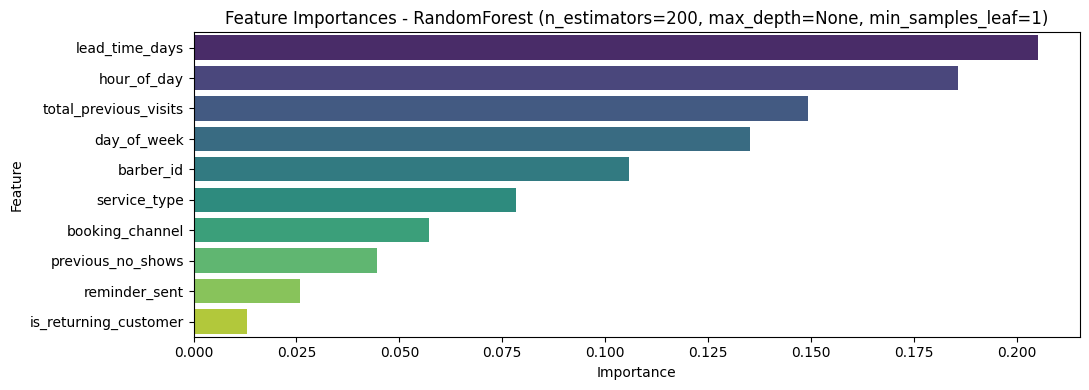

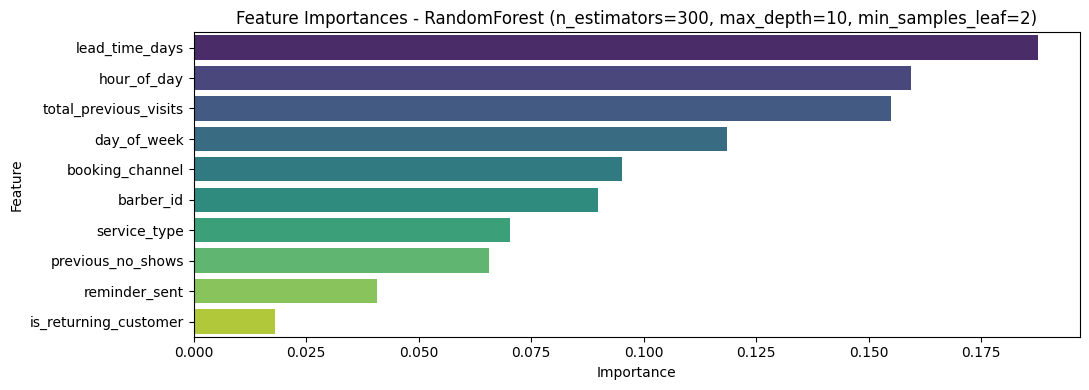

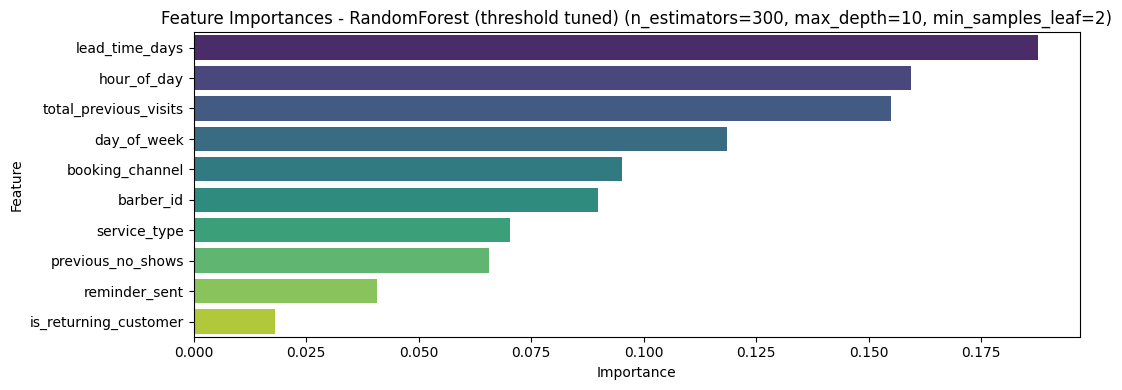

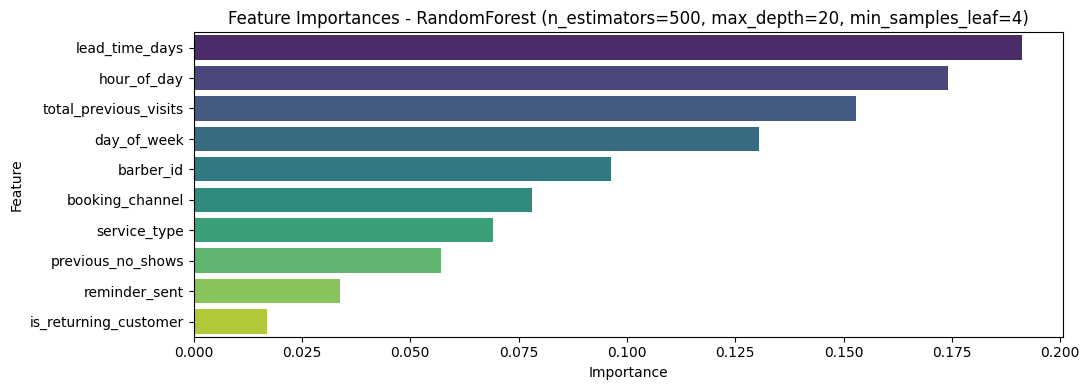

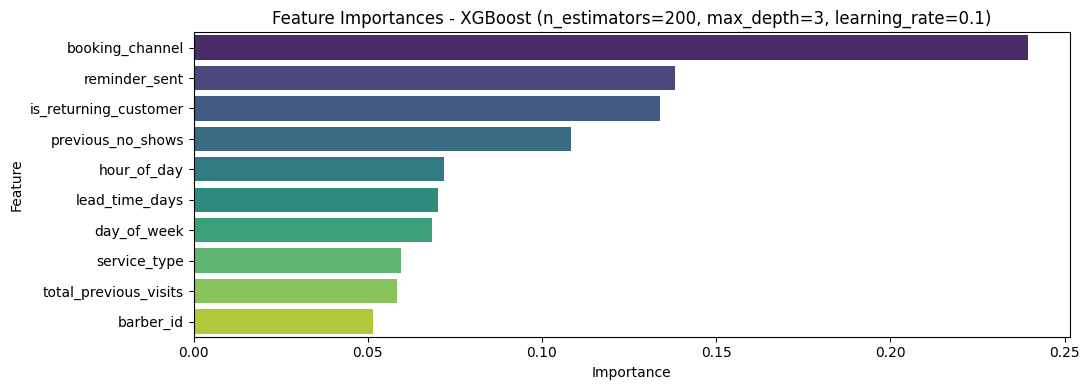

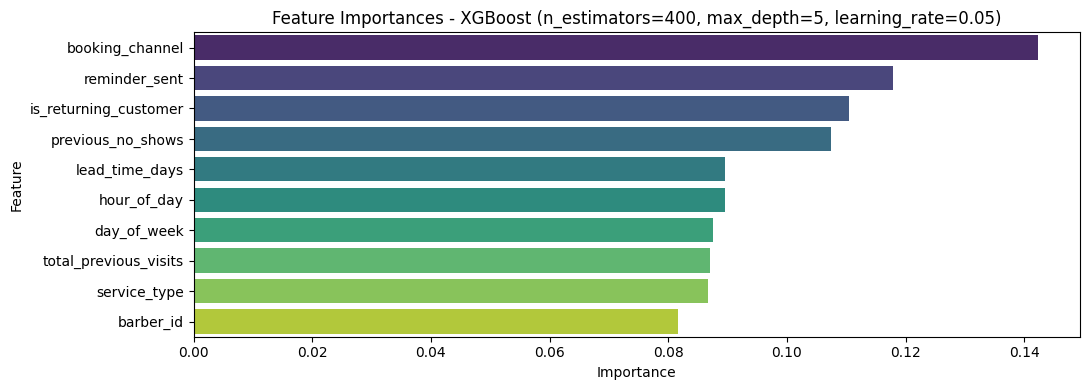

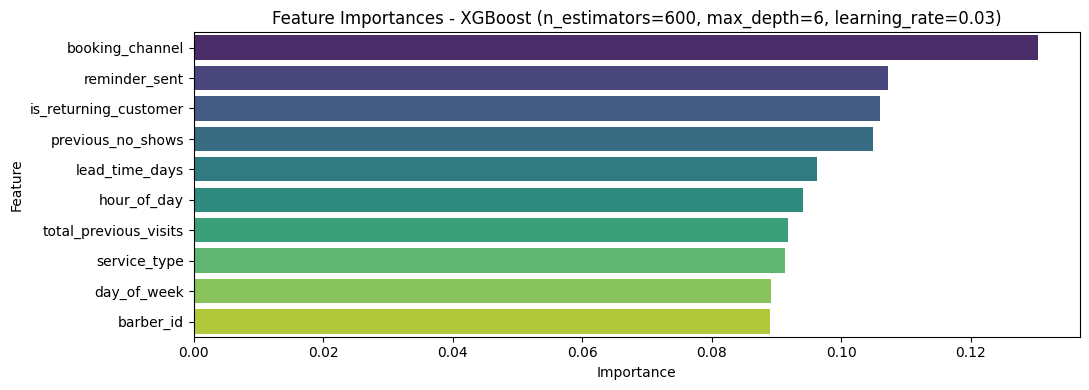

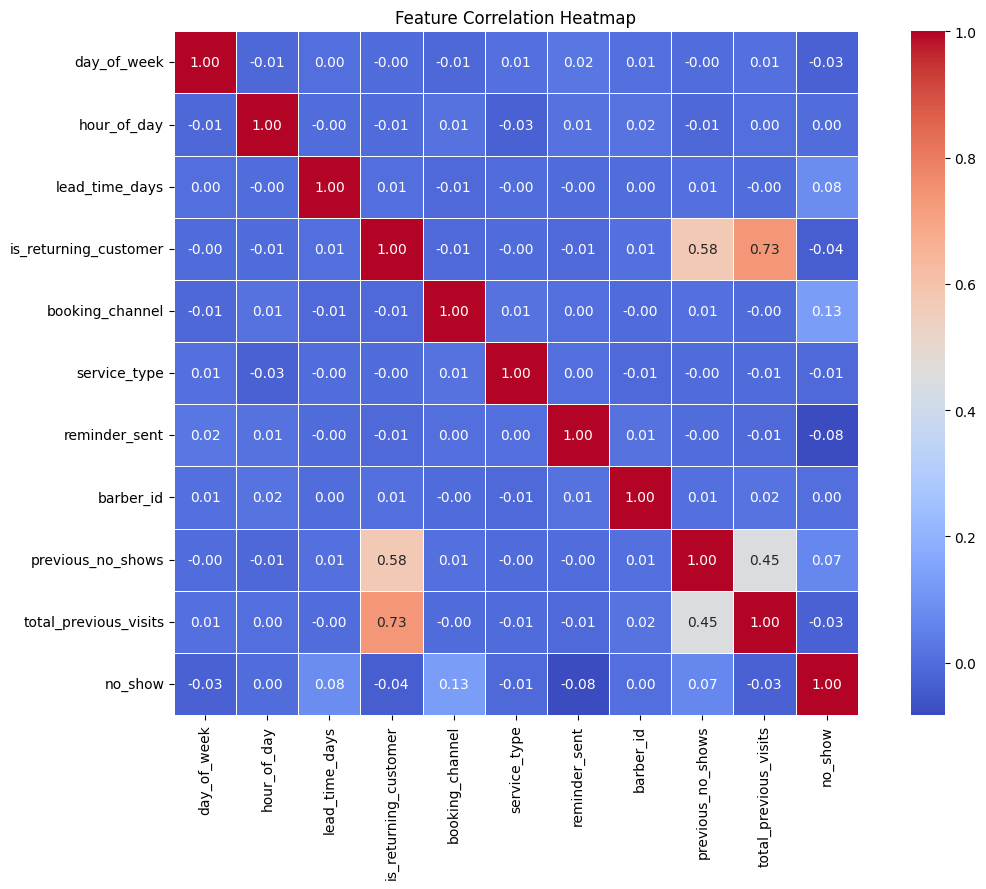

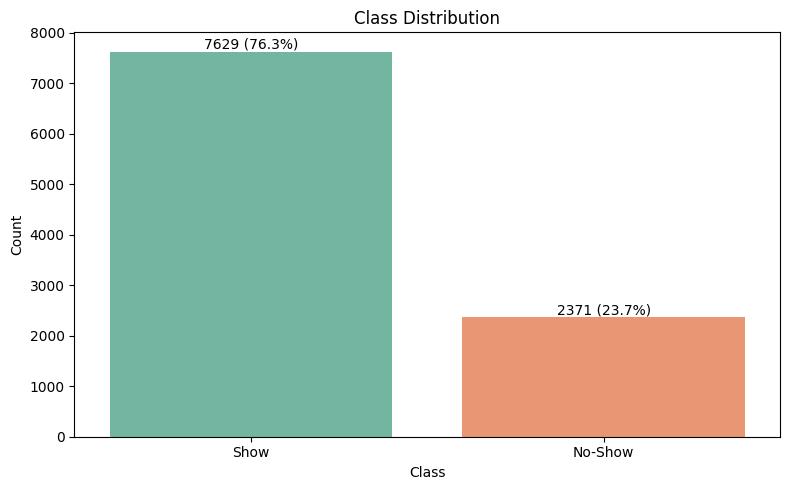

In [ ]:
models_for_viz = [
    {
        'name': 'RandomForest',
        'model': rf_1,
        'params': {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1},
    },
    {
        'name': 'RandomForest',
        'model': rf_2,
        'params': {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 2},
    },
    {
        'name': 'RandomForest (threshold tuned)',
        'model': rf_2_tuned,
        'params': {'n_estimators': 300, 'max_depth': 10, 'min_samples_leaf': 2},
    },
    {
        'name': 'RandomForest',
        'model': rf_3,
        'params': {'n_estimators': 500, 'max_depth': 20, 'min_samples_leaf': 4},
    },
    {
        'name': 'XGBoost',
        'model': xgb_1,
        'params': {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.10},
    },
    {
        'name': 'XGBoost',
        'model': xgb_2,
        'params': {'n_estimators': 400, 'max_depth': 5, 'learning_rate': 0.05},
    },
    {
        'name': 'XGBoost',
        'model': xgb_3,
        'params': {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.03},
    },
]

plot_feature_importances(models_for_viz, FEATURES, top_n=len(FEATURES), figsize=(11, 4))
plot_correlation_heatmap(df[FEATURES + [TARGET]], figsize=(12, 9))
plot_class_distribution(df[TARGET], labels=('Show', 'No-Show'))